In [1]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, ArrayType, IntegerType, StructType,StructField
import numpy as np
from math import log, exp
from pyspark.sql import SparkSession
import os
import sys
import pandas as pd
import time
JAVA_HOME_PATH = "/usr/lib/jvm/java-17-openjdk-amd64"
# JAVA_HOME_PATH = 'C:/Program Files/Java/jdk-17'
# HADOOP_HOME = 'C:/hadoop'
# Установка критических переменных окружения
os.environ["JAVA_HOME"] = JAVA_HOME_PATH
os.environ["PATH"] = f"{JAVA_HOME_PATH}/bin:{os.environ['PATH']}"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
#os.environ['HADOOP_HOME'] = HADOOP_HOME



spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

spark.conf.set("spark.sql.execution.pyspark.udf.faulthandler.enabled", "true")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/03 13:19:59 WARN Utils: Your hostname, pc, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/05/03 13:19:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/03 13:20:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("translated_and_english_combined_file.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [3]:
import pandas as pd

pd.read_csv("combined_data.csv").head()

,label,email
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [4]:
spark.range(5).show()

+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



In [5]:
df.printSchema()
df.show(10)

root
 |-- label: integer (nullable = false)
 |-- email: string (nullable = true)



26/05/03 13:20:22 WARN TaskSetManager: Stage 1 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.


+-----+--------------------+
|label|               email|
+-----+--------------------+
|    1|ounce feather bow...|
|    1|wulvob get your m...|
|    0| computer connect...|
|    1|university degree...|
|    0|thanks for all yo...|
|    0|larry king live a...|
|    0|michael pobega wr...|
|    0|hi i have this er...|
|    1|works gateway wor...|
|    1|upon this account...|
+-----+--------------------+
only showing top 10 rows


In [6]:
# model.get("lottery")
# model.get("sale")

In [7]:
# def predict_bayes(word):
#     word = word.lower()
#     num_spam_with_word = model[word]['spam']
#     num_ham_with_word = model[word]['ham']
#     return 1.0*num_spam_with_word/(num_spam_with_word + num_ham_with_word)

In [8]:
# predict_bayes("sale")

In [9]:
# print(type(local_data))

In [10]:
# emails = new_df

# def predict_naive_bayes(email):
#     total = emails.count()
#     num_spam = emails.where("label=1").count()
#     num_ham = total - num_spam
    
#     # Исправление опечатки
#     words = set(email.strip().split())
    
#     log_spam_prob = log(num_spam / total)  # Логарифм P(спам)
#     log_ham_prob = log(num_ham / total)    # Логарифм P(не спам)
    
#     alpha = 1e-6  # Параметр сглаживания для новых слов
    
#     for word in words:
#         if word in model:
#             # Правильное вычисление логарифмов вероятностей
#             log_spam_prob += log(model[word]['spam'] / num_spam)
#             log_ham_prob += log(model[word]['ham'] / num_ham)
#         else:
#             # Сглаживание для новых слов
#             log_spam_prob += log(alpha)
#             log_ham_prob += log(alpha)
    
#     # Преобразуем обратно в вероятности с защитой от переполнения
#     log_ratio = log_spam_prob - log_ham_prob
#     probability = 1 / (1 + exp(-log_ratio))
    
#     return probability

In [11]:
# predict_naive_bayes("meet me at")

In [12]:
# predict_naive_bayes("lottery sale")

In [13]:
# predict_naive_bayes("hi mom how are you")

In [14]:
# predict_naive_bayes("a")

In [15]:
# predict_naive_bayes("hi dad")

In [16]:
# predict_naive_bayes("meet me at the lobby of the hotel at nine am")

In [17]:
# small_df = spark.read.csv("emails.csv", header=True)
# small_df.printSchema()
# small_df.show(20)

In [18]:
# model.get("mom")

In [19]:
# model.get("hi")

In [20]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import NaiveBayes
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
bayes_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=500000, minDF=5)
# 4. Классификатор
nb = NaiveBayes(featuresCol="features", labelCol="label", modelType="multinomial")

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, nb])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
bayes_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = bayes_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
bayes_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {bayes_accuracy:.4f}")
bayes_end = time.time()

26/05/03 13:20:23 WARN TaskSetManager: Stage 2 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:20:30 WARN TaskSetManager: Stage 6 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:20:35 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 13:20:35 WARN TaskSetManager: Stage 9 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:20:35 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
[Stage 9:=====================================================>   (16 + 1) / 17]

Accuracy: 0.9464


In [21]:
from pyspark.sql import Row

# 1. Создаём DataFrame с новым сообщением
new_text = "hi mom how are you?"
new_df = spark.createDataFrame([Row(email=new_text)])

# 2. Прогоняем через модель
prediction = bayes_model.transform(new_df)

# 3. Смотрим результат
prediction.select("email", "prediction").show()

26/05/03 13:20:37 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 13:20:39 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 13:20:39 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 13:20:39 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


+-------------------+----------+
|              email|prediction|
+-------------------+----------+
|hi mom how are you?|       0.0|
+-------------------+----------+



In [22]:
bayes_model.write().overwrite().save("models/spam_model_bayes")

26/05/03 13:20:43 WARN TaskSetManager: Stage 19 contains a task of very large size (3015 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:20:46 WARN TaskSetManager: Stage 21 contains a task of very large size (2143 KiB). The maximum recommended task size is 1000 KiB.


In [23]:
from pyspark.ml.pipeline import PipelineModel

loaded_model = PipelineModel.load("models/spam_model_bayes")
new_text = "hi mom how are you?"
new_df = spark.createDataFrame([Row(email=new_text)])

# 2. Прогоняем через модель
prediction = loaded_model.transform(new_df)

# 3. Смотрим результат
prediction.select("email", "prediction").show()

26/05/03 13:20:50 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 13:20:50 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 13:20:50 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 13:20:51 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


+-------------------+----------+
|              email|prediction|
+-------------------+----------+
|hi mom how are you?|       0.0|
+-------------------+----------+



In [24]:
new_text = "hi mom how are you"
new_df = spark.createDataFrame([Row(email=new_text)])

# 2. Прогоняем через модель
prediction = loaded_model.transform(new_df)

# 3. Смотрим результат
prediction.select("email", "prediction").show()

26/05/03 13:20:52 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 13:20:52 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 13:20:52 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 13:20:52 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


+------------------+----------+
|             email|prediction|
+------------------+----------+
|hi mom how are you|       0.0|
+------------------+----------+



In [25]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
lr_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=100000, minDF=1)
# 4. Классификатор
lr = LogisticRegression(featuresCol="features", labelCol="label")

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, lr])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
lr_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = lr_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
lr_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {lr_accuracy:.4f}")
lr_end = time.time()

26/05/03 13:20:53 WARN TaskSetManager: Stage 43 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:20:57 WARN TaskSetManager: Stage 47 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:20:59 WARN TaskSetManager: Stage 50 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:21:03 WARN TaskSetManager: Stage 53 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:21:03 WARN TaskSetManager: Stage 56 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:21:03 WARN TaskSetManager: Stage 59 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:21:03 WARN TaskSetManager: Stage 62 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.

Accuracy: 0.9743


In [26]:
print(df.count())
print(df.where("label>0").count())
print(df.where("label=1").count())
print(df.where("label=0").count())

26/05/03 13:21:22 WARN TaskSetManager: Stage 367 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.


166748


26/05/03 13:21:23 WARN TaskSetManager: Stage 370 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:21:23 WARN TaskSetManager: Stage 373 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.


87814
87814
78934


26/05/03 13:21:23 WARN TaskSetManager: Stage 376 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.


In [27]:
lr_model.write().overwrite().save("models/spam_model_lr")

26/05/03 13:21:27 WARN TaskSetManager: Stage 383 contains a task of very large size (2222 KiB). The maximum recommended task size is 1000 KiB.


In [28]:
spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("translated_and_english_combined_file.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [29]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import DecisionTreeClassifier

from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
dt_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=100000, minDF=1)
# 4. Классификатор
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, dt])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
dt_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = dt_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
dt_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {dt_accuracy:.4f}")
dt_end = time.time()

26/05/03 13:21:32 WARN TaskSetManager: Stage 0 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:21:37 WARN TaskSetManager: Stage 4 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:21:37 WARN TaskSetManager: Stage 7 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:21:37 WARN TaskSetManager: Stage 8 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:21:40 WARN DAGScheduler: Broadcasting large task binary with size 1048.0 KiB
26/05/03 13:21:40 WARN TaskSetManager: Stage 9 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:21:50 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
26/05/03 13:21:50 WARN TaskSetManager: Stage 11 contains a task of very large size (16595 KiB). The maximum recomme

Accuracy: 0.7818


In [30]:
dt_model.write().overwrite().save("models/spam_model_dt")

26/05/03 13:23:39 WARN TaskSetManager: Stage 27 contains a task of very large size (2222 KiB). The maximum recommended task size is 1000 KiB.


In [31]:
spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("translated_and_english_combined_file.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [32]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import RandomForestClassifier

from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
rf_start = time.time()
df = df.filter(df.email.isNotNull())
# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")
# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
# 3. Векторизация
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features",vocabSize=100000, minDF=1)
# 4. Классификатор
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50)

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, rf])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение
rf_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = rf_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
rf_accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {rf_accuracy:.4f}")
rf_end = time.time()

26/05/03 13:23:46 WARN TaskSetManager: Stage 0 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:23:50 WARN TaskSetManager: Stage 4 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:23:50 WARN TaskSetManager: Stage 7 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:23:50 WARN TaskSetManager: Stage 8 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:23:52 WARN DAGScheduler: Broadcasting large task binary with size 1048.1 KiB
26/05/03 13:23:52 WARN TaskSetManager: Stage 9 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:24:00 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
26/05/03 13:24:00 WARN TaskSetManager: Stage 11 contains a task of very large size (16595 KiB). The maximum recomme

Accuracy: 0.7529


In [33]:
rf_model.write().overwrite().save("models/spam_model_rf")

26/05/03 13:25:04 WARN TaskSetManager: Stage 27 contains a task of very large size (2222 KiB). The maximum recommended task size is 1000 KiB.


In [34]:
spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("translated_and_english_combined_file.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [35]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import LinearSVC  # Импорт SVM
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Фильтрация пустых значений
svm_start = time.time()
df = df.filter(df.email.isNotNull())

# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")

# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# 3. Векторизация
vectorizer = CountVectorizer(
    inputCol="filtered", 
    outputCol="features",
    vocabSize=100000, 
    minDF=1
)

# 4. Классификатор SVM (LinearSVC)
svm = LinearSVC(
    featuresCol="features", 
    labelCol="label",
    maxIter=10,          # Количество итераций
    regParam=0.1         # Параметр регуляризации
)

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, svm])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение модели
svm_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = svm_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)
svm_accuracy = evaluator.evaluate(predictions)
print(f"SVM Accuracy: {svm_accuracy:.4f}")
svm_end = time.time()
# Дополнительные метрики (F1, Precision, Recall)
evaluator.setMetricName("f1").evaluate(predictions)
evaluator.setMetricName("weightedPrecision").evaluate(predictions)
evaluator.setMetricName("weightedRecall").evaluate(predictions)

26/05/03 13:25:16 WARN TaskSetManager: Stage 0 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:25:19 WARN TaskSetManager: Stage 4 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:25:22 WARN TaskSetManager: Stage 7 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:25:24 WARN TaskSetManager: Stage 10 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:25:25 WARN TaskSetManager: Stage 13 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:25:25 WARN TaskSetManager: Stage 16 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:25:25 WARN TaskSetManager: Stage 19 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26

SVM Accuracy: 0.9763


26/05/03 13:25:33 WARN TaskSetManager: Stage 74 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:25:34 WARN TaskSetManager: Stage 76 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

0.9762968328705381

In [36]:
svm_model.write().overwrite().save("models/spam_model_svm")

26/05/03 13:25:39 WARN TaskSetManager: Stage 82 contains a task of very large size (2222 KiB). The maximum recommended task size is 1000 KiB.


In [37]:
spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "32g") \
    .config("spark.executor.memory", "32g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("translated_and_english_combined_file.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [38]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import GBTClassifier  # Импорт GBT
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
gbt_start = time.time()
# Фильтрация пустых значений
df = df.filter(df.email.isNotNull())

# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")

# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# 3. Векторизация
vectorizer = CountVectorizer(
    inputCol="filtered", 
    outputCol="features",
    vocabSize=10000, 
    minDF=1
)

# 4. Классификатор GBT (Gradient-Boosted Trees)
gbt = GBTClassifier(
    featuresCol="features", 
    labelCol="label",
    maxIter=50,           # Количество деревьев (аналог n_estimators)
    maxDepth=5,           # Глубина дерева
    stepSize=0.1,         # Скорость обучения (learning rate)
    subsamplingRate=0.8,  # Доля данных для каждого дерева
    seed=42
)

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, gbt])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение модели
gbt_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = gbt_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)
gbt_accuracy = evaluator.evaluate(predictions)
print(f"GBT Accuracy: {gbt_accuracy:.4f}")
gbt_end = time.time()
# Дополнительные метрики
print(f"F1-score: {evaluator.setMetricName('f1').evaluate(predictions):.4f}")
print(f"Precision: {evaluator.setMetricName('weightedPrecision').evaluate(predictions):.4f}")
print(f"Recall: {evaluator.setMetricName('weightedRecall').evaluate(predictions):.4f}")

26/05/03 13:25:47 WARN TaskSetManager: Stage 0 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:25:49 WARN TaskSetManager: Stage 4 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:25:49 WARN TaskSetManager: Stage 5 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:25:52 WARN TaskSetManager: Stage 6 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:25:55 WARN TaskSetManager: Stage 8 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:26:00 WARN TaskSetManager: Stage 10 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:26:01 WARN TaskSetManager: Stage 12 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/0

GBT Accuracy: 0.9070


26/05/03 13:28:47 WARN TaskSetManager: Stage 510 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:28:50 WARN TaskSetManager: Stage 512 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.


F1-score: 0.9064


26/05/03 13:28:51 WARN TaskSetManager: Stage 514 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.


Precision: 0.9126


[Stage 514:================================================>      (15 + 2) / 17]

Recall: 0.9070


In [39]:
gbt_model.write().overwrite().save("models/spam_model_gbt")

In [40]:
print("bayes_accuracy:", bayes_accuracy, 'time', bayes_end - bayes_start)
print("lr_accuracy:", lr_accuracy, 'time', lr_end - lr_start)
print("dt_accuracy:", dt_accuracy, 'time', dt_end - dt_start)
print("svm_accurac:", svm_accuracy, 'time', svm_end - svm_start)
print("gbt_accuracy:", gbt_accuracy, 'time', gbt_end - gbt_start)
print("rf_accuracy:", rf_accuracy, 'time', rf_end - rf_start)

bayes_accuracy: 0.9463559901806914 time 14.016618967056274
lr_accuracy: 0.9743048009980281 time 29.70810890197754
dt_accuracy: 0.7817618415227977 time 123.34399008750916
svm_accurac: 0.976296832870538 time 14.968973159790039
gbt_accuracy: 0.9070385126162018 time 180.6053409576416
rf_accuracy: 0.7529478047406334 time 75.02262449264526


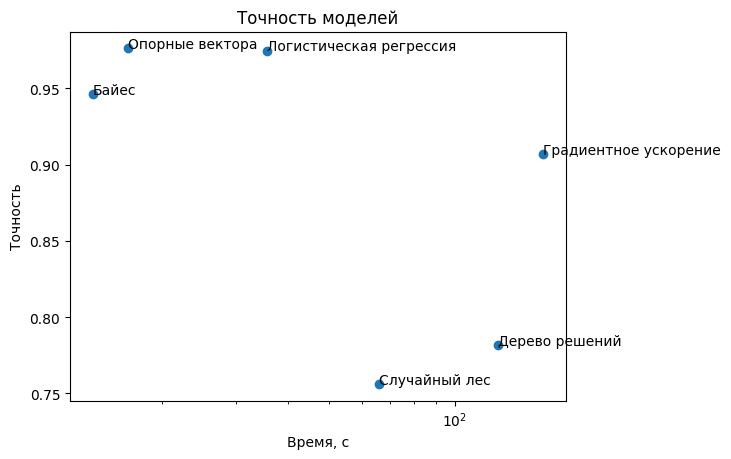

In [41]:
# Create the plot as requested

import matplotlib.pyplot as plt

# Data from the user
models = ["Байес", "Логистическая регрессия", "Дерево решений", "Опорные вектора", "Градиентное ускорение", "Случайный лес"]
accuracy = [0.9463559901806914, 0.9747675962815405, 0.7816411123184032, 0.9762767113364723, 0.9070385126162018, 0.7560062779186285]
time_sec = [13.65663743019104, 35.54560589790344, 126.84595847129822, 16.590663194656372, 162.83224296569824, 65.89334487915039]

plt.figure()

# Scatter plot
plt.scatter(time_sec, accuracy)

# Annotate points with model names
for i, model in enumerate(models):
    plt.annotate(model, (time_sec[i], accuracy[i]))

# Use logarithmic scale for time axis to handle uneven scale
plt.xscale('log')

plt.xlabel("Время, с")
plt.ylabel("Точность")
plt.title("Точность моделей")

plt.show()

In [42]:
spark.stop()

spark = SparkSession.builder \
    .appName("SpamFilter") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.executor.cores", "12") \
    .config("spark.executor.instances", "12") \
    .config("spark.default.parallelism", "32") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.driver.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "  # Использовать Garbage Collector G1
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .config("spark.executor.extraJavaOptions", 
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.nio=ALL-UNNAMED "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "-XX:+UseG1GC "
            "-XX:+IgnoreUnrecognizedVMOptions") \
    .getOrCreate()

schema = StructType([
    StructField("label", IntegerType(), True),  # Метка как целое число
    StructField("email", StringType(), True)    # Текст письма как строка
])
pdf = pd.read_csv("translated_and_english_combined_file.csv")

df = spark.createDataFrame(pdf)

df = df.withColumn(
    "label",
    F.when(F.col("label").isNull(), 0)
     .when(F.col("label") >= 1, 1)
     .otherwise(0)
)

In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer
from pyspark.ml.classification import LinearSVC  # Импорт SVM
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Фильтрация пустых значений
svm_start = time.time()
df = df.filter(df.email.isNotNull())

# 1. Токенизация
tokenizer = Tokenizer(inputCol="email", outputCol="words")

# 2. Удаление стоп-слов
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# 3. Векторизация
vectorizer = CountVectorizer(
    inputCol="filtered", 
    outputCol="features",
    vocabSize=100_000_000, 
    minDF=1
)

# 4. Классификатор SVM (LinearSVC)
svm = LinearSVC(
    featuresCol="features", 
    labelCol="label",
    maxIter=1000,          # Количество итераций
    regParam=0.1         # Параметр регуляризации
)

# 5. Пайплайн
pipeline = Pipeline(stages=[tokenizer, remover, vectorizer, svm])

# 6. Разделение на train/test
train_data, test_data = df.randomSplit([0.7, 0.3], seed=42)

# 7. Обучение модели
svm_model = pipeline.fit(train_data)

# 8. Предсказания
predictions = svm_model.transform(test_data)

# 9. Оценка качества
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)
svm_accuracy = evaluator.evaluate(predictions)
print(f"SVM Accuracy: {svm_accuracy:.4f}")
svm_end = time.time()
# Дополнительные метрики (F1, Precision, Recall)
evaluator.setMetricName("f1").evaluate(predictions)
evaluator.setMetricName("weightedPrecision").evaluate(predictions)
evaluator.setMetricName("weightedRecall").evaluate(predictions)

26/05/03 13:29:12 WARN TaskSetManager: Stage 0 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:29:19 WARN TaskSetManager: Stage 4 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:29:23 WARN TaskSetManager: Stage 7 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:29:28 WARN TaskSetManager: Stage 10 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:29:28 WARN TaskSetManager: Stage 13 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:29:28 WARN TaskSetManager: Stage 16 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26/05/03 13:29:28 WARN TaskSetManager: Stage 19 contains a task of very large size (16595 KiB). The maximum recommended task size is 1000 KiB.
26

In [ ]:
print("SVM:", svm_accuracy, 'time', svm_end - svm_start)